# Straight Line, Plane and Hyperplane

## Quick revision notes
These ideas help ML models draw a boundary between groups, for example `spam` and `not spam`.

## 1. A straight line in 2D
A straight line is written as:

$$y = mx + c$$

You may also see the same line written as:

$$y = β_0 + β_1x$$

Here, $β_1$ does the job of slope $m$, and $β_0$ does the job of intercept $c$.

- $m$ is the **slope**: how steep the line is.
- $c$ is the **intercept**: where the line touches the y-axis.

**Example:** $y = 2x + 1$ means: move right by 1, then move up by 2. The line starts at height 1.

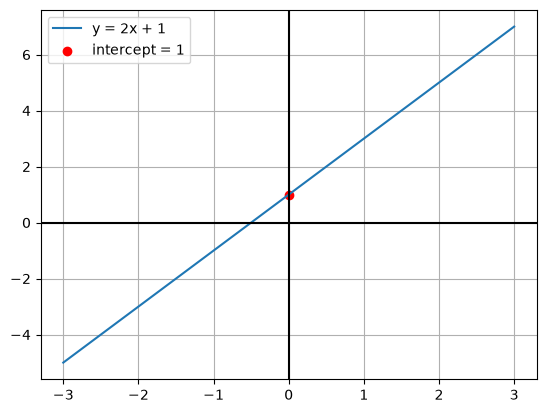

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 100)
y = 2 * x + 1
plt.plot(x, y, label='y = 2x + 1')
plt.scatter([0], [1], color='red', label='intercept = 1')
plt.axhline(0, color='black'); plt.axvline(0, color='black')
plt.grid(); plt.legend(); plt.show()

**What the diagram shows:** the red dot is the starting height, and the blue line goes up as it moves right. This is what slope means.

## 2. Another way to write a line
A line can also be written as:

$$ax + by + c = 0$$

To make $y$ stand alone, do these tiny steps:

$$by = -ax - c$$

$$y = (-a/b)x - c/b$$

So the slope is $-a/b$ and the y-intercept is $-c/b$.

**Example:** $2x - y + 3 = 0$ becomes $y = 2x + 3$. It is the same line written in another way.

In [2]:
a, b, c = 2, -1, 3
slope = -a / b
intercept = -c / b
print('Slope:', slope)
print('Y-intercept:', intercept)

Slope: 2.0
Y-intercept: 3.0


**What the code does:** it changes the second form into slope and intercept values, so the line is easier to understand and draw.

## 3. ML version of the same idea
In machine learning, we often write the boundary as:

$$w^T x + b = 0$$

### When is $w^T x = 0$?
The expression $w^T x$ is the dot product of $w$ and $x$:

$$w^T x = w_1x_1 + w_2x_2 + \cdots + w_nx_n$$

$w^T x = 0$ when the weighted sum is zero. Geometrically, this means that $x$ is perpendicular to the weight vector $w$ (assuming $w \ne 0$), because $w^T x = ||w||||x||\cos(\theta)$ and the dot product is zero when $\theta = 90^\circ$. If $b=0$, all such points lie on the boundary through the origin. For the general boundary $w^T x+b=0$, the condition is instead $w^T x=-b$.

With two features, this is the longer version:

$$w_1x_1 + w_2x_2 + b = 0$$

- $x$ = input values (features).
- $w$ = weights; they say how important each feature is.
- $b$ = bias/intercept; it moves the boundary.

**Example:** put $w = [2, -1]$, $x = [1, 5]$, and $b = 3$ into the equation. The answer is 0, so the point sits exactly on the line.

In [4]:
w = np.array([2, -1])
x = np.array([1, 5])
b = 3
print('Boundary value:', w @ x + b)

Boundary value: 0


**What the code does:** it puts one point into the boundary equation. A result of 0 means “the point is on the line.”

## 4. Line, plane, and hyperplane

| Number of features | Boundary name | Simple picture |
|---|---|---|
| 2 features | Line | A flat line on paper |
| 3 features | Plane | A flat sheet in space |
| More than 3 features | Hyperplane | A boundary we cannot easily draw |

For many features, the long equation is:

$$w_1x_1 + w_2x_2 + ... + w_nx_n + b = 0$$

The short equation stays similar:

$$w^T x + b = 0$$

Only the number of features changes.

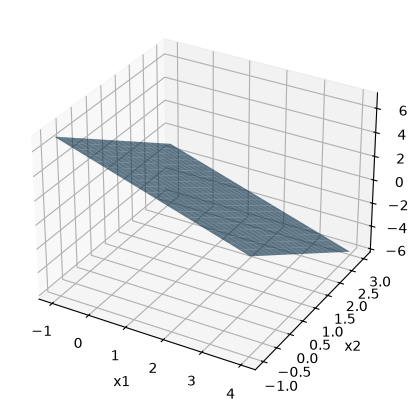

In [4]:
from mpl_toolkits.mplot3d import Axes3D
grid_x, grid_y = np.meshgrid(np.linspace(-1, 4, 20), np.linspace(-1, 3, 20))
grid_z = 4 - grid_x - 2 * grid_y  # x + 2y + z - 4 = 0
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, alpha=0.65)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
plt.show()

**What the diagram shows:** with three features, the boundary is no longer a line. It becomes a flat sheet called a plane.

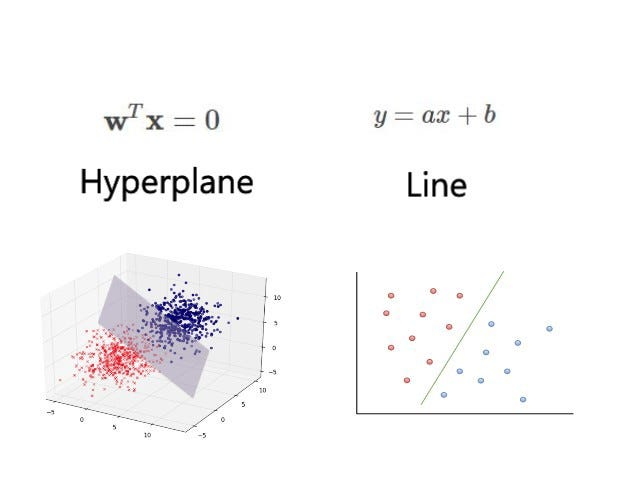

## 5. Distance from a point to a plane — like you are 5

Imagine the plane is a **flat floor** and the point is a **ball floating above it**. To find the distance, do not walk sideways across the floor. Go straight to the closest spot on the floor.

That shortest path meets the plane at a **right angle (90°)**. It is called a **perpendicular** path.

The arrow that points straight out of the plane is the **normal vector** $w$. It tells us the correct shortest-path direction.

For a plane $w^T x + b = 0$ and a point $s$, the distance is:

$$distance = \frac{|w^T s + b|}{||w||}$$

Read it slowly:

- $w^T s + b$ tells us how far the point is pushed away from the plane.
- $||w||$ fixes the answer when the normal arrow is longer or shorter.
- The bars $| |$ make the final distance positive—distance is never negative.

**Remember:** the sign before taking $| |$ only says which side of the plane the point is on.

Point: [3. 1. 4.]
Closest point on the plane: [ 2.17 -0.67  3.17]
Shortest distance: 2.04


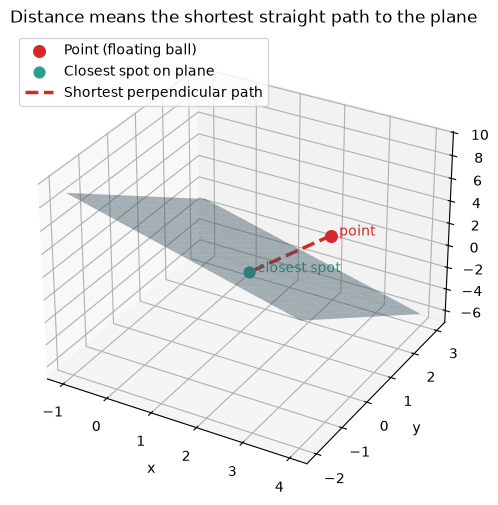

In [3]:
# Plane: x + 2y + z - 4 = 0.  Think of it as a flat sheet.
weights = np.array([1.0, 2.0, 1.0])   # This arrow is perpendicular to the plane.
bias = -4.0
point = np.array([3.0, 1.0, 4.0])     # Our floating ball.

# Step 1: signed distance tells the side. Step 2: abs() gives the real distance.
signed_distance = (weights @ point + bias) / np.linalg.norm(weights)
distance = abs(signed_distance)

# This is the closest spot on the plane (the ball's 'landing spot').
closest_point = point - signed_distance * weights / np.linalg.norm(weights)

print(f'Point: {point}')
print(f'Closest point on the plane: {closest_point.round(2)}')
print(f'Shortest distance: {distance:.2f}')

# Draw the flat sheet, the floating point, and the shortest right-angle path.
grid_x, grid_y = np.meshgrid(np.linspace(-1, 4, 25), np.linspace(-2, 3, 25))
grid_z = 4 - grid_x - 2 * grid_y
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, color='#8ecae6', alpha=0.45)
ax.scatter(*point, color='#d62828', s=70, label='Point (floating ball)')
ax.scatter(*closest_point, color='#2a9d8f', s=60, label='Closest spot on plane')
ax.plot([point[0], closest_point[0]], [point[1], closest_point[1]],
        [point[2], closest_point[2]], '--', color='#d62828', linewidth=2.5,
        label='Shortest perpendicular path')
ax.text(*point, '  point', color='#d62828')
ax.text(*closest_point, '  closest spot', color='#2a9d8f')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Distance means the shortest straight path to the plane')
ax.legend(loc='upper left')
plt.show()

**What the diagram shows:** red is the floating point. Green is the closest place it can land on the flat sheet. The dashed red line is the shortest possible path, so its length is the distance.

On paper (2 features), the plane becomes a line. The same idea still works: draw the shortest right-angle path from the point to the line.

## Why this matters in ML
A classifier checks the sign of:

$$w^T x + b$$

- positive → one group
- negative → the other group
- zero → exactly on the boundary

**Memory trick:** 2 features = line, 3 features = plane, many features = hyperplane.